In [1]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


torch.Size([100000, 1])
torch.Size([100000, 3])
torch.Size([100000, 3])
torch.Size([100000, 3])
Epoch 100, Loss: 0.04750163501398875
Epoch 200, Loss: 0.03717535525626715
Epoch 300, Loss: 0.026099945278642695
Epoch 400, Loss: 0.0206823100916948
Epoch 500, Loss: 0.020260275266833272
Epoch 600, Loss: 0.02021169428044601
Epoch 700, Loss: 0.020201814701333604
Epoch 800, Loss: 0.020192052489407752
Epoch 900, Loss: 0.020218540115945052
Epoch 1000, Loss: 0.02018735005092461


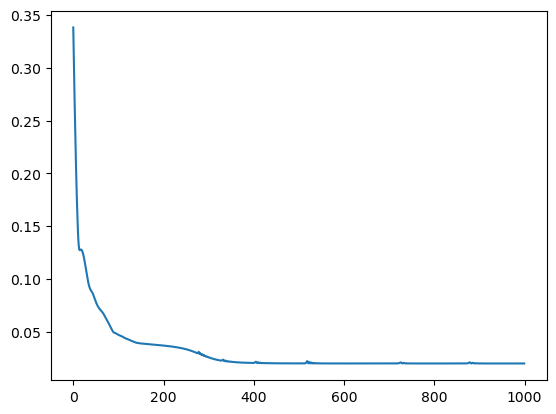

In [2]:
import qRegNN as qrnn

Xtrain = 2*np.pi*np.random.rand(100000).reshape(-1,1)
Ytrain = np.random.normal(loc=np.sin(Xtrain),scale=0.1)
quantiles = np.array([0.05,0.5,0.95])
Ytrain = Ytrain.repeat(len(quantiles),axis=1)

Xtrain = torch.tensor(Xtrain).to(device)
Ytrain = torch.tensor(Ytrain).to(device)
quantiles = torch.tensor(quantiles).to(device)
model = qrnn.qreg(1,quantiles,widths=[50,50,50,50])
model = model.double()
model = model.cuda()
qrnn.train(model,Xtrain,Ytrain,lr=1e-3,n_epoch=1000)

In [3]:
xtest = np.linspace(0,2*np.pi,num=1000)
y = np.random.normal(loc=np.sin(xtest),scale=0.1)
yp = model(torch.tensor(xtest.reshape(-1,1))).detach().cpu().numpy()

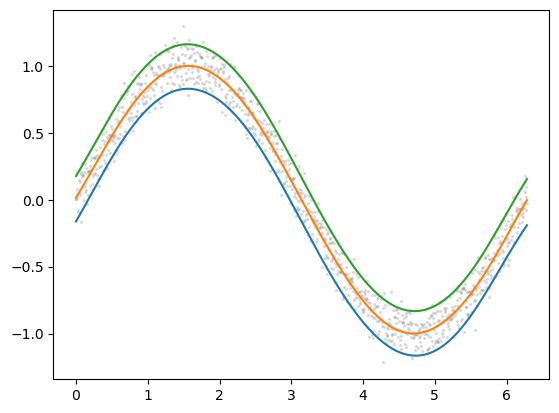

In [4]:
plt.scatter(xtest,y,s=2,color='gray',alpha=0.2)
plt.plot(xtest,yp[:,0])
plt.plot(xtest,yp[:,1])
plt.plot(xtest,yp[:,2])

# Try with data

In [5]:
year = 2017
additional_vars = ['jet1_pt','jet1_eta','jet1_phi','jet2_pt','jet2_eta','jet2_phi']
data,unnorm_data,mass_data,names = hf.LAPS_train("DATA",year,num_batches=5,Mjj_cut=800,pt_cut=300,additional=additional_vars)
bkg,unnorm_bkg,mass_bkg,names = hf.LAPS_train("QCDBKG",year,num_batches=-1,Mjj_cut=800,pt_cut=300,additional=additional_vars)

# normalize to data mean/std
mean = data.mean(axis=0)
std = data.std(axis=0)

data = (data-mean)/std
bkg = (bkg-mean)/std

In [6]:
bkg_pt1 = bkg[:,names.index("jet1_pt")]
bkg_eta1 = bkg[:,names.index("jet1_eta")]
bkg_phi1 = bkg[:,names.index("jet1_phi")]
bkg_pt2 = bkg[:,names.index("jet2_pt")]
bkg_eta2 = bkg[:,names.index("jet2_eta")]
bkg_phi2 = bkg[:,names.index("jet2_phi")]

data_pt1 = data[:,names.index("jet1_pt")]
data_eta1 = data[:,names.index("jet1_eta")]
data_phi1 = data[:,names.index("jet1_phi")]
data_pt2 = data[:,names.index("jet2_pt")]
data_eta2 = data[:,names.index("jet2_eta")]
data_phi2 = data[:,names.index("jet2_phi")]

Text(0.5, 0, 'jet 2 phi')

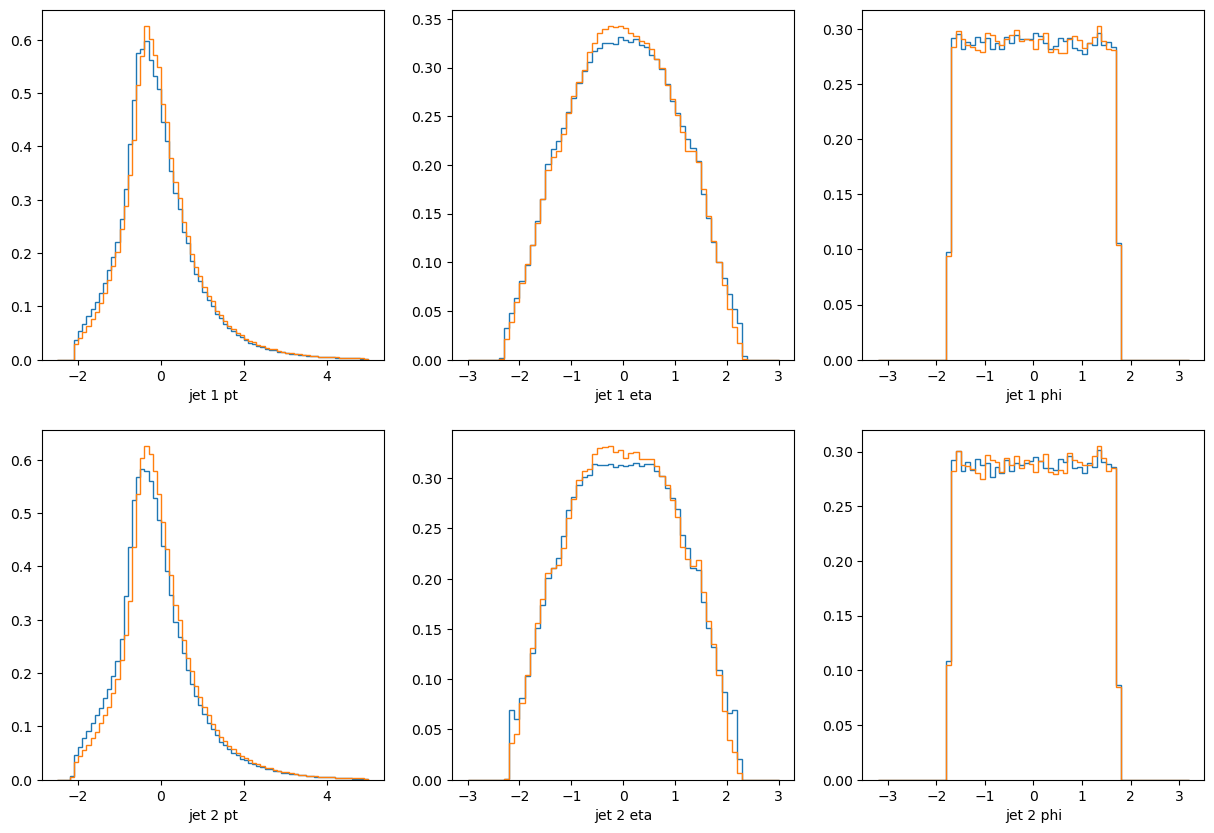

In [7]:
plt.figure(figsize=(15,10))

plt.subplot(231)
h = plt.hist(bkg_pt1,bins=np.arange(-2.5,5.1,step=0.1),density=True,histtype='step')
h = plt.hist(data_pt1,bins=np.arange(-2.5,5.1,step=0.1),density=True,histtype='step')
plt.xlabel("jet 1 pt")

plt.subplot(232)
h = plt.hist(bkg_eta1,bins=np.arange(-3,3.1,step=0.1),density=True,histtype='step')
h = plt.hist(data_eta1,bins=np.arange(-3,3.1,step=0.1),density=True,histtype='step')
plt.xlabel("jet 1 eta")

plt.subplot(233)
h = plt.hist(bkg_phi1,bins=np.arange(-3.2,3.3,step=0.1),density=True,histtype='step')
h = plt.hist(data_phi1,bins=np.arange(-3.2,3.3,step=0.1),density=True,histtype='step')
plt.xlabel("jet 1 phi")

plt.subplot(234)
h = plt.hist(bkg_pt2,bins=np.arange(-2.5,5.1,step=0.1),density=True,histtype='step')
h = plt.hist(data_pt2,bins=np.arange(-2.5,5.1,step=0.1),density=True,histtype='step')
plt.xlabel("jet 2 pt")

plt.subplot(235)
h = plt.hist(bkg_eta2,bins=np.arange(-3,3.1,step=0.1),density=True,histtype='step')
h = plt.hist(data_eta2,bins=np.arange(-3,3.1,step=0.1),density=True,histtype='step')
plt.xlabel("jet 2 eta")

plt.subplot(236)
h = plt.hist(bkg_phi2,bins=np.arange(-3.2,3.3,step=0.1),density=True,histtype='step')
h = plt.hist(data_phi2,bins=np.arange(-3.2,3.3,step=0.1),density=True,histtype='step')
plt.xlabel("jet 2 phi")

# Try re-weighting pT using phi

torch.Size([100000, 1])
torch.Size([100000, 23])
torch.Size([100000, 23])
torch.Size([100000, 23])
Epoch 100, Loss: 0.22781473752023557
Epoch 200, Loss: 0.22744729658127288
Epoch 300, Loss: 0.2273627555301643
Epoch 400, Loss: 0.22732953768509348
Epoch 500, Loss: 0.22731278940066274
Epoch 600, Loss: 0.22730243150758464
Epoch 700, Loss: 0.2272958671213664
Epoch 800, Loss: 0.22729168929860208
Epoch 900, Loss: 0.22728882164360012
Epoch 1000, Loss: 0.22728654669441561


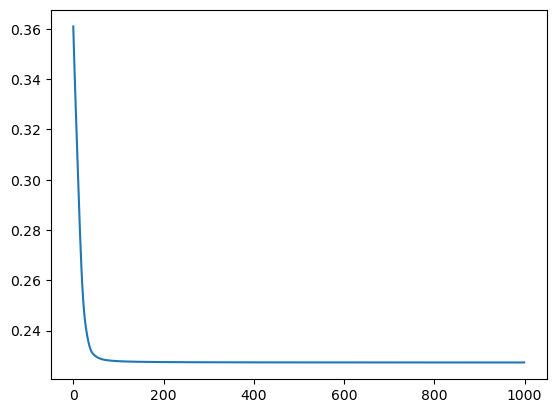

In [89]:
# train quantile regression on data
quantiles = np.array([0.001,0.01,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,0.99,0.999])
Xtrain = data_phi1[:100000].reshape(-1,1)
Ytrain = data_pt1[:100000].reshape(-1,1).repeat(len(quantiles),axis=1)
Xtrain = torch.tensor(Xtrain).to(device)
Ytrain = torch.tensor(Ytrain).to(device)
quantiles = torch.tensor(quantiles).to(device)
data_model = qrnn.qreg(Xtrain.shape[1],quantiles,widths=[50,50,50])
data_model = data_model.cuda()
qrnn.train(data_model,Xtrain,Ytrain,n_epoch=1000,lr=1e-3,check=100)

torch.Size([100000, 1])
torch.Size([100000, 23])
torch.Size([100000, 23])
torch.Size([100000, 23])
Epoch 100, Loss: 0.22721812631961047
Epoch 200, Loss: 0.22686398579998177
Epoch 300, Loss: 0.22677518503843538
Epoch 400, Loss: 0.2267393314563478
Epoch 500, Loss: 0.22672211646077
Epoch 600, Loss: 0.22671278452789806
Epoch 700, Loss: 0.22670719445354703
Epoch 800, Loss: 0.2267037360901331
Epoch 900, Loss: 0.2267014095989691
Epoch 1000, Loss: 0.2266998415177168


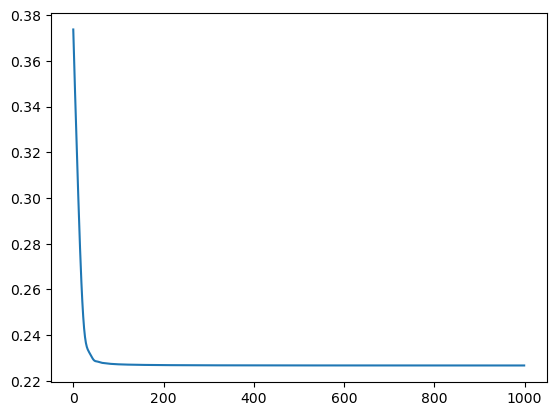

In [90]:
# train quantile regression on bkg
quantiles = np.array([0.001,0.01,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,0.99,0.999])
Xtrain = bkg_phi1[:100000].reshape(-1,1)
Ytrain = bkg_pt1[:100000].reshape(-1,1).repeat(len(quantiles),axis=1)
Xtrain = torch.tensor(Xtrain).to(device)
Ytrain = torch.tensor(Ytrain).to(device)
quantiles = torch.tensor(quantiles).to(device)
bkg_model = qrnn.qreg(Xtrain.shape[1],quantiles,widths=[50,50,50])
bkg_model = bkg_model.cuda()
qrnn.train(bkg_model,Xtrain,Ytrain,n_epoch=1000,lr=1e-3,check=100)

In [92]:
# vectorized function for binning outputs
def getBins(x,b):
    out = []
    for i,xval in enumerate(x):
        out.append(np.digitize(xval,b[i]))
    return np.array(out)
#vGetBins = np.vectorize(getBins,otypes=[int])

qprobs = quantiles.detach().cpu().numpy()
qprobs = np.array(list(qprobs))
nbins = len(qprobs)-1

# evaluate quantiles on bkg
data_ptQuantiles = data_model(torch.tensor(bkg_phi1.reshape(-1,1)).to(device)).detach().cpu().numpy()
bkg_ptQuantiles = bkg_model(torch.tensor(bkg_phi1.reshape(-1,1)).to(device)).detach().cpu().numpy()

# bin pTs into quantile bins using background model
#data_ptBins = vGetBins(bkg_pt1,data_ptQuantiles)
print('start binning')
bkg_ptBins = getBins(bkg_pt1,bkg_ptQuantiles)
print('end binning')

# over/under-flow stay unchanged
over_under = (bkg_ptBins==0) | (bkg_ptBins==nbins+1)
bkg_unchanged = bkg_pt1[over_under]

# select non-over/under-flow
bkg_toChange = bkg_pt1[~over_under]
bkg_ptBins = bkg_ptBins[~over_under]
#data_ptBins = data_ptBins[~over_under]

# calculate slopes & correct pT
plo = qprobs[bkg_ptBins-1]
phi = qprobs[bkg_ptBins]

ybl = np.take_along_axis(bkg_ptQuantiles[~over_under],(bkg_ptBins-1).reshape(-1,1),1).flatten()
ybh = np.take_along_axis(bkg_ptQuantiles[~over_under],(bkg_ptBins).reshape(-1,1),1).flatten()
mb = (phi-plo)/(ybh-ybl)

ydl = np.take_along_axis(data_ptQuantiles[~over_under],(bkg_ptBins-1).reshape(-1,1),1).flatten()
ydh = np.take_along_axis(data_ptQuantiles[~over_under],(bkg_ptBins).reshape(-1,1),1).flatten()
md = (phi-plo)/(ydh-ydl)

ptCorr = ydl + (mb/md)*(bkg_toChange - ybl)

ptFinal = np.concatenate((ptCorr,bkg_unchanged))

start binning
end binning


Text(0.5, 0, 'Jet 1 $p_T$ (shifted/scaled)')

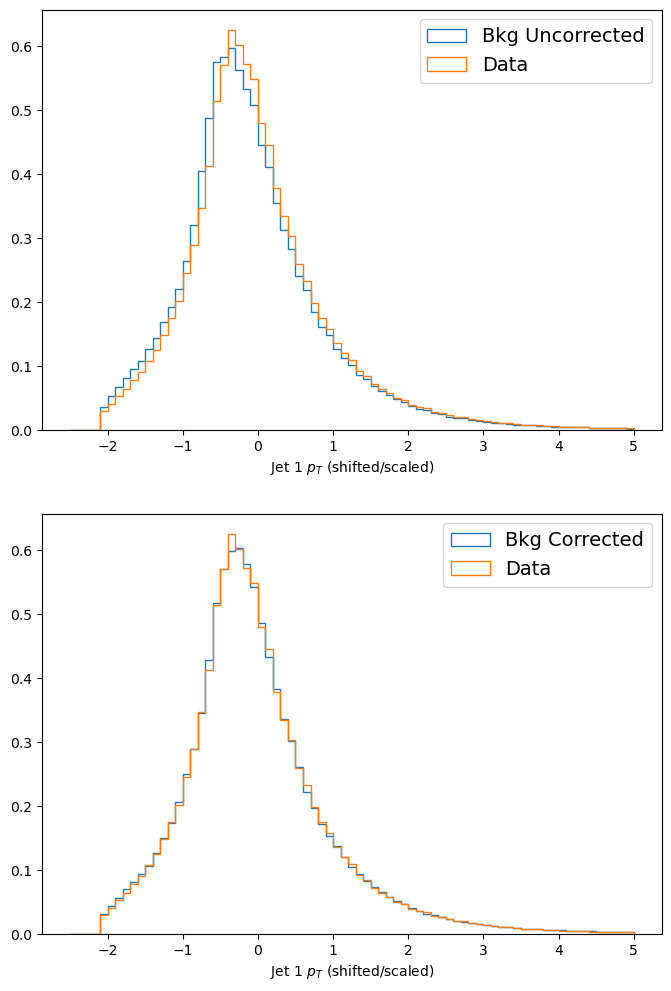

In [93]:
plt.figure(figsize=(8,12))
plt.subplot(211)
h = plt.hist(bkg_pt1,bins=np.arange(-2.5,5.1,step=0.1),density=True,histtype='step',label='Bkg Uncorrected')
h = plt.hist(data_pt1,bins=np.arange(-2.5,5.1,step=0.1),density=True,histtype='step',label='Data')
plt.legend(loc='upper right',fontsize=14)
plt.xlabel(r"Jet 1 $p_T$ (shifted/scaled)")

plt.subplot(212)
h = plt.hist(ptFinal,bins=np.arange(-2.5,5.1,step=0.1),density=True,histtype='step',label="Bkg Corrected")
h = plt.hist(data_pt1,bins=np.arange(-2.5,5.1,step=0.1),density=True,histtype='step',label="Data")
plt.legend(loc='upper right',fontsize=14)
plt.xlabel(r"Jet 1 $p_T$ (shifted/scaled)")

In [39]:
data_j1_kin = np.concatenate((data_pt1.reshape(-1,1),data_eta1.reshape(-1,1),data_phi1.reshape(-1,1)),axis=1)
data_j2_kin = np.concatenate((data_pt2.reshape(-1,1),data_eta2.reshape(-1,1),data_phi2.reshape(-1,1)),axis=1)
data_inputs = data[:,:14]

bkg_j1_kin = np.concatenate((bkg_pt1.reshape(-1,1),bkg_eta1.reshape(-1,1),bkg_phi1.reshape(-1,1)),axis=1)
bkg_j2_kin = np.concatenate((bkg_pt2.reshape(-1,1),bkg_eta2.reshape(-1,1),bkg_phi2.reshape(-1,1)),axis=1)
bkg_inputs = bkg[:,:14]

In [22]:
data_df = pd.DataFrame.from_dict({var:data[:,i] for i,var in enumerate(names)})
bkg_df = pd.DataFrame.from_dict({var:bkg[:,i] for i,var in enumerate(names)})

torch.Size([100000, 3])
torch.Size([100000, 21])
torch.Size([100000, 21])
torch.Size([100000, 21])
Epoch 100, Loss: 0.2589634619799247
Epoch 200, Loss: 0.2592486072292963
Epoch 300, Loss: 0.25880832648682417
Epoch 400, Loss: 0.2588131973428618
Epoch 500, Loss: 0.25873725111882545
Epoch 600, Loss: 0.2587228902453374
Epoch 700, Loss: 0.258700651615926
Epoch 800, Loss: 0.2586496668244042
Epoch 900, Loss: 0.2586638573730701
Epoch 1000, Loss: 0.25847869091824366


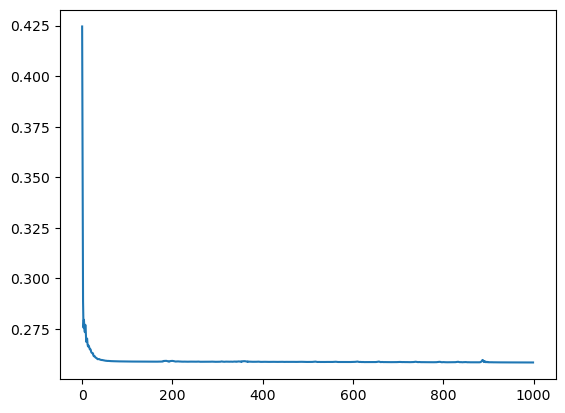

In [59]:
# train quantile regression on data
quantiles = np.array([0.01,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,0.99])
#quantiles = np.array([0.1,0.5,0.9])
Xtrain = data_j1_kin
Ytrain = data_inputs[:,0].reshape(-1,1).repeat(len(quantiles),axis=1)

Xtrain = Xtrain[:100000]
Ytrain = Ytrain[:100000]

Xtrain = torch.tensor(Xtrain).to(device)
Ytrain = torch.tensor(Ytrain).to(device)
quantiles = torch.tensor(quantiles).to(device)
data_model = qrnn.qreg(Xtrain.shape[1],quantiles,widths=[500,500,500])
#model = model.double()
data_model = data_model.cuda()
qrnn.train(data_model,Xtrain,Ytrain,n_epoch=1000,lr=1e-3,check=100)

torch.Size([100000, 3])
torch.Size([100000, 21])
torch.Size([100000, 21])
torch.Size([100000, 21])
Epoch 100, Loss: 0.250481333719709
Epoch 200, Loss: 0.25050288574901164
Epoch 300, Loss: 0.2504240612682225
Epoch 400, Loss: 0.2503146261660047
Epoch 500, Loss: 0.25044361065916715
Epoch 600, Loss: 0.2507331492960733
Epoch 700, Loss: 0.25021615535712044
Epoch 800, Loss: 0.2501085715770254
Epoch 900, Loss: 0.24999974594906546
Epoch 1000, Loss: 0.2499988986821431


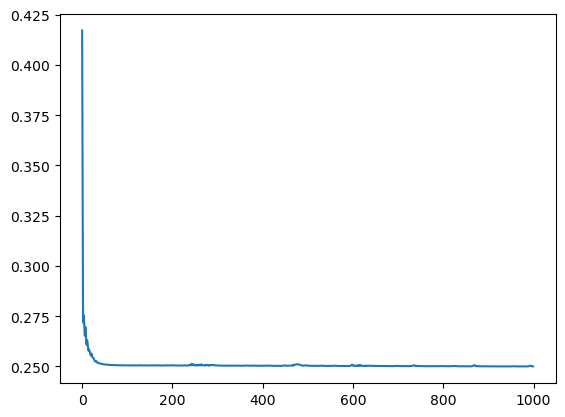

In [61]:
# train quantile regression on data
quantiles = np.array([0.01,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,0.99])
#quantiles = np.array([0.1,0.5,0.9])
Xtrain = bkg_j1_kin
Ytrain = bkg_inputs[:,0].reshape(-1,1).repeat(len(quantiles),axis=1)

Xtrain = Xtrain[:100000]
Ytrain = Ytrain[:100000]

Xtrain = torch.tensor(Xtrain).to(device)
Ytrain = torch.tensor(Ytrain).to(device)
quantiles = torch.tensor(quantiles).to(device)
bkg_model = qrnn.qreg(Xtrain.shape[1],quantiles,widths=[500,500,500])
#model = model.double()
bkg_model = bkg_model.cuda()
qrnn.train(bkg_model,Xtrain,Ytrain,n_epoch=1000,lr=1e-3,check=100)

In [74]:
idx = 100000 + 10
xtest = bkg_j1_kin[idx].reshape(1,-1)
ytest_bkg = bkg_inputs[:,0].reshape(-1,1)[idx]
qbkg = bkg_model(torch.tensor(xtest)).detach().cpu().numpy().flatten()
qdata = data_model(torch.tensor(xtest)).detach().cpu().numpy().flatten()
qprobs = quantiles.detach().cpu().numpy()

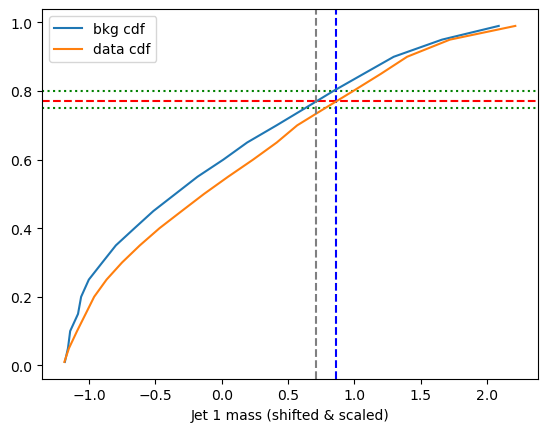

In [75]:
plt.plot(qbkg,qprobs,zorder=2,label='bkg cdf')
plt.plot(qdata,qprobs,zorder=2,label='data cdf')
plt.axvline(ytest_bkg.flatten(),color='gray',linestyle='--')
bkg_bin = np.digitize(ytest_bkg.flatten(),qbkg)[0]

p1 = qprobs[bkg_bin-1]
p2 = qprobs[bkg_bin]
plt.axhline(p1,color='green',linestyle=':',zorder=1)
plt.axhline(p2,color='green',linestyle=':',zorder=1)

ybl = qbkg[bkg_bin-1]
ybh = qbkg[bkg_bin]
mb = (p2-p1)/(ybh-ybl)

ydl = qdata[bkg_bin-1]
ydh = qdata[bkg_bin]
md = (p2-p1)/(ydh-ydl)

ycorr = ydl + (mb/md)*(ytest_bkg.flatten()[0] - ybl)
qest = p1 + mb*(ytest_bkg.flatten()[0] - ybl)
plt.axhline(qest,color='red',linestyle="--",zorder=1)
plt.axvline(ycorr,color='blue',linestyle='--',zorder=1)

blo = qbkg[bkg_bin-1]
bhi = qbkg[bkg_bin]

plt.xlabel("Jet 1 mass (shifted & scaled)")
plt.legend(loc='best')

#plt.xlim([1.0,1.25])
#plt.ylim([0.7,1.0])

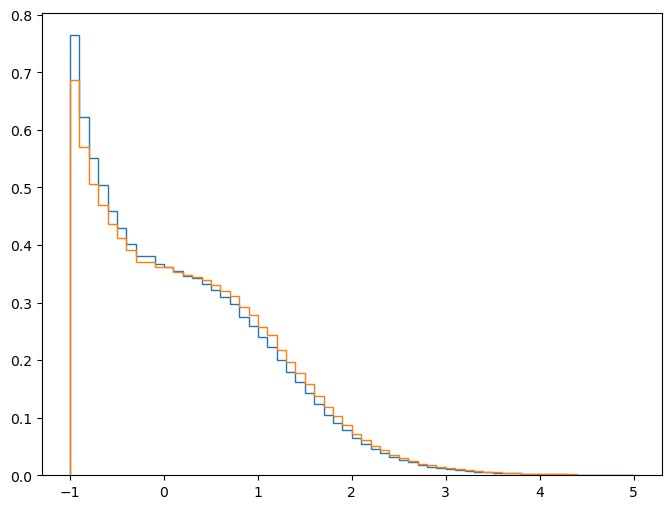

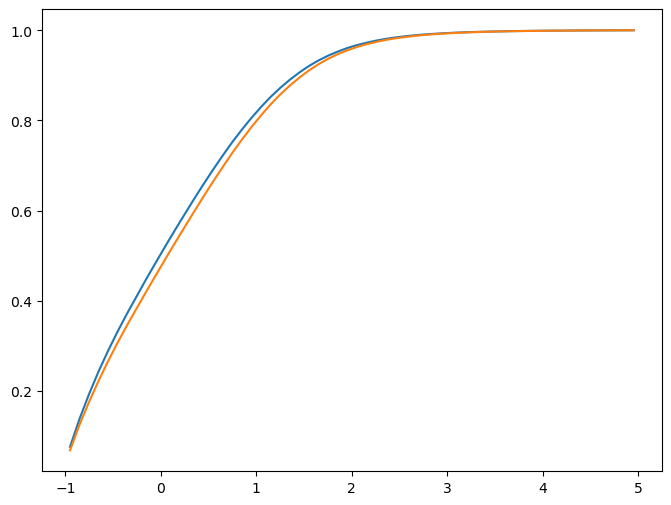

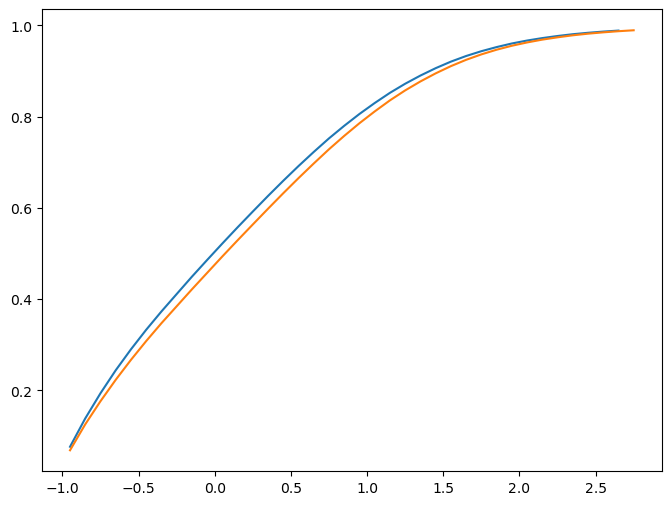

In [78]:
plt.figure(figsize=(8,6))
bins = np.arange(-1,5.1,step=0.1)
n1,b1,p1 = plt.hist(bkg_inputs[:,0],bins=bins,density=True,histtype='step')
n2,b2,p2 = plt.hist(data_inputs[:,0],bins=bins,density=True,histtype='step')

xvals = (bins[1:] + bins[:-1])/2
qb_all = np.cumsum(n1)/np.sum(n1)
qd_all = np.cumsum(n2)/np.sum(n2)

plt.figure(figsize=(8,6))
plt.plot(xvals,qb_all)
plt.plot(xvals,qd_all)

plt.figure(figsize=(8,6))
msk_bkg_all = (qb_all>=0.01) & (qb_all <= 0.99)
msk_dat_all = (qd_all>=0.01) & (qd_all <= 0.99)
plt.plot(xvals[msk_bkg_all],qb_all[msk_bkg_all])
plt.plot(xvals[msk_dat_all],qd_all[msk_dat_all])

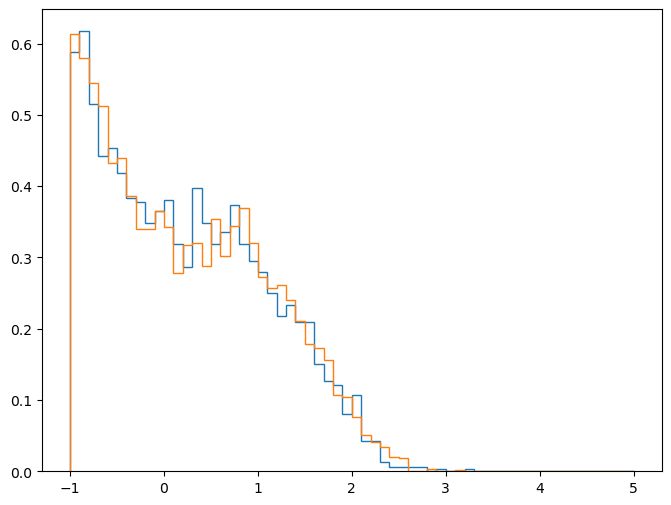

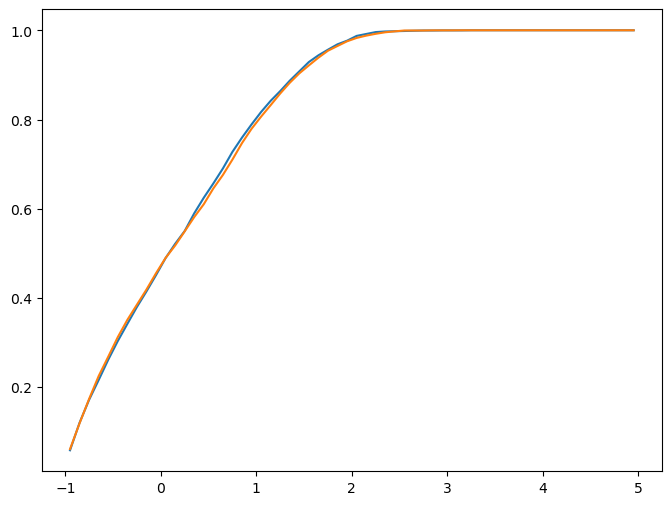

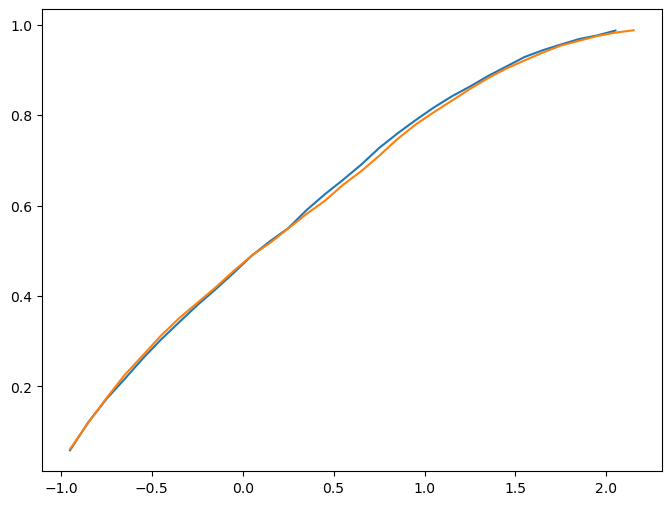

In [79]:
bkg_ind = np.all(np.abs(bkg_j1_kin - xtest)<0.2,axis=1)
data_ind = np.all(np.abs(data_j1_kin - xtest)<0.2,axis=1)

plt.figure(figsize=(8,6))
bins = np.arange(-1,5.1,step=0.1)
n1,b1,p1 = plt.hist(bkg_inputs[bkg_ind][:,0],bins=bins,density=True,histtype='step')
n2,b2,p2 = plt.hist(data_inputs[data_ind][:,0],bins=bins,density=True,histtype='step')

xvals = (bins[1:] + bins[:-1])/2
qb_cut = np.cumsum(n1)/np.sum(n1)
qd_cut = np.cumsum(n2)/np.sum(n2)

plt.figure(figsize=(8,6))
plt.plot(xvals,qb_cut)
plt.plot(xvals,qd_cut)

plt.figure(figsize=(8,6))
msk_bkg_cut = (qb_cut>=0.01) & (qb_cut <= 0.99)
msk_dat_cut = (qd_cut>=0.01) & (qd_cut <= 0.99)
plt.plot(xvals[msk_bkg_cut],qb_cut[msk_bkg_cut])
plt.plot(xvals[msk_dat_cut],qd_cut[msk_dat_cut])

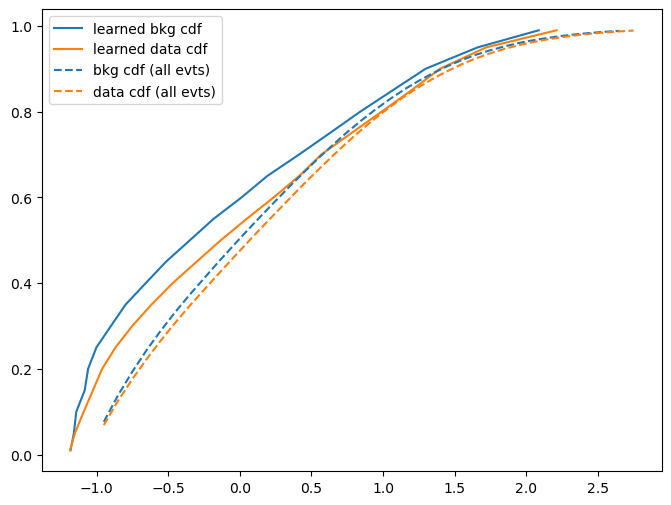

In [83]:
plt.figure(figsize=(8,6))

plt.plot(qbkg,qprobs,label='learned bkg cdf',color="C0")
plt.plot(qdata,qprobs,label='learned data cdf',color="C1")

plt.plot(xvals[msk_bkg_all],qb_all[msk_bkg_all],label="bkg cdf (all evts)",color="C0",linestyle="--")
plt.plot(xvals[msk_dat_all],qd_all[msk_dat_all],label="data cdf (all evts)",color="C1",linestyle="--")

plt.legend(loc='best')

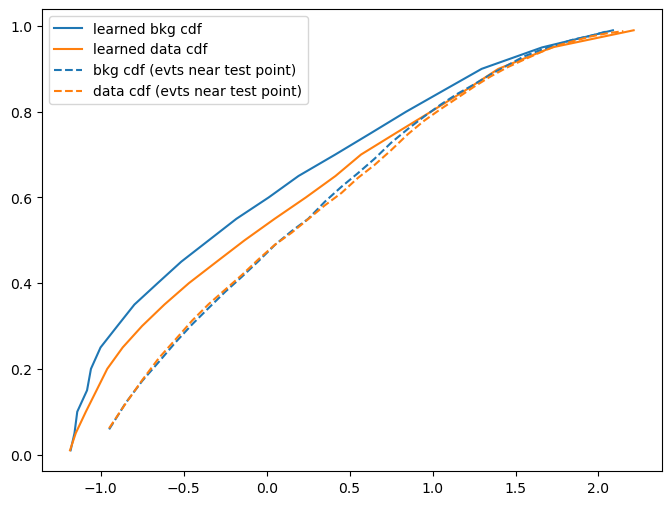

In [84]:
plt.figure(figsize=(8,6))

plt.plot(qbkg,qprobs,label='learned bkg cdf',color="C0")
plt.plot(qdata,qprobs,label='learned data cdf',color="C1")

plt.plot(xvals[msk_bkg_cut],qb_cut[msk_bkg_cut],label="bkg cdf (evts near test point)",color="C0",linestyle="--")
plt.plot(xvals[msk_dat_cut],qd_cut[msk_dat_cut],label="data cdf (evts near test point)",color="C1",linestyle="--")

plt.legend(loc='best')